# Módulo 01 — Notebook 2: Fundamentos do Scikit-learn

## Objetivos desta aula

Ao final deste notebook, você será capaz de:
- Entender a **API Estimator** do scikit-learn (`fit`, `transform`, `predict`)
- Usar **Pipelines** do sklearn para encadear pré-processamento e modelos
- Aplicar **Transformadores** padrão (StandardScaler, PCA, LabelEncoder)
- Realizar **validação cruzada** e **busca de hiperparâmetros** básica

---

## Por que o scikit-learn?

O scikit-learn é a biblioteca de ML mais usada no mundo Python. Ela implementa, de forma coerente, os padrões de projeto que vimos no notebook anterior. **Todos os estimadores têm a mesma interface**, o que permite:

- Trocar um modelo por outro com uma linha
- Combinar etapas em Pipelines
- Usar as mesmas ferramentas de avaliação para qualquer modelo


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn — pré-processamento
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

# sklearn — modelos
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# sklearn — pipeline e seleção de modelos
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, learning_curve
)
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# sklearn — datasets de demonstração
from sklearn.datasets import make_classification, make_blobs

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('white')
print('Scikit-learn carregado:', __import__('sklearn').__version__)

Scikit-learn carregado: 1.8.0


---

## Parte 1: A API Estimator

Toda classe do sklearn segue o mesmo protocolo:

| Método | Quem tem? | O que faz? |
|---|---|---|
| `fit(X, y)` | Todos | Aprende parâmetros a partir dos dados |
| `transform(X)` | Transformadores | Aplica transformação nos dados |
| `predict(X)` | Classificadores/Regressores | Faz predições |
| `fit_transform(X)` | Transformadores | `fit` + `transform` em uma chamada |
| `score(X, y)` | Modelos supervisionados | Avalia o modelo (acurácia por padrão) |

**Regra de ouro:** Sempre `fit` nos dados de treino, `transform`/`predict` em qualquer conjunto!


##### Gerando um dataset de demonstração

In [16]:
X, y = make_blobs(
    n_samples=300,
    centers=3,           # 3 classes (emoções)
    n_features=5,        # 5 features de áudio
    cluster_std=2.5,
    random_state=42
)

nomes_classes = {0: 'Neutro', 1: 'Alegria', 2: 'Tristeza'}
print(f'Dataset: {X.shape[0]} amostras, {X.shape[1]} features, {len(np.unique(y))} classes')
print(f'Classes: {nomes_classes}')

# Split treino/teste ANTES de qualquer pré-processamento!
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTreino: {X_treino.shape[0]} amostras')
print(f'Teste:  {X_teste.shape[0]} amostras')

Dataset: 300 amostras, 5 features, 3 classes
Classes: {0: 'Neutro', 1: 'Alegria', 2: 'Tristeza'}

Treino: 240 amostras
Teste:  60 amostras


##### 1.1 Pré-processamento com StandardScaler

In [18]:
scaler = StandardScaler()

X_treino_scaled = scaler.fit_transform(X_treino)  # aprende μ e σ do treino, aplica
X_teste_scaled  = scaler.transform(X_teste)       # usa μ e σ DO TREINO
# (?) Qual a diferença entre eles? Por que não usamos fit_transform no teste?

print('Antes da normalização (treino):')
print(f'  Média: {X_treino.mean(axis=0).round(2)}')
print(f'  Std:   {X_treino.std(axis=0).round(2)}')

print('\nApós normalização (treino):')
print(f'  Média: {X_treino_scaled.mean(axis=0).round(6)}')
print(f'  Std:   {X_treino_scaled.std(axis=0).round(6)}')

print('\nApós normalização (teste):')
print(f'  Média: {X_teste_scaled.mean(axis=0).round(6)}')
print(f'  Std:   {X_teste_scaled.std(axis=0).round(6)}')

print('\nParâmetros aprendidos pelo scaler:')
print(f'  Médias (μ):    {scaler.mean_.round(2)}')
print(f'  Desvios (σ):   {scaler.scale_.round(2)}')

Antes da normalização (treino):
  Média: [-6.18  3.35  6.26 -0.46 -3.07]
  Std:   [3.84 9.08 2.61 4.59 5.52]

Após normalização (treino):
  Média: [-0.  0. -0.  0. -0.]
  Std:   [1. 1. 1. 1. 1.]

Após normalização (teste):
  Média: [-0.145746 -0.058305 -0.049164 -0.102583  0.073282]
  Std:   [1.002056 0.950675 1.009373 0.890741 1.016029]

Parâmetros aprendidos pelo scaler:
  Médias (μ):    [-6.18  3.35  6.26 -0.46 -3.07]
  Desvios (σ):   [3.84 9.08 2.61 4.59 5.52]


##### 1.2 Classificação com KNN

In [23]:
knn = KNeighborsClassifier(n_neighbors=7)

# Treinar
knn.fit(X_treino_scaled, y_treino)

# Avaliar
y_pred = knn.predict(X_teste_scaled)
acuracia = accuracy_score(y_teste, y_pred)

print(f'Acurácia no teste: {acuracia:.3f}')

# Relatório detalhado
print('\nRelatório de Classificação:')
print(classification_report(
    y_teste, y_pred,
    target_names=list(nomes_classes.values())
))

Acurácia no teste: 0.967

Relatório de Classificação:
              precision    recall  f1-score   support

      Neutro       1.00      0.90      0.95        20
     Alegria       1.00      1.00      1.00        20
    Tristeza       0.91      1.00      0.95        20

    accuracy                           0.97        60
   macro avg       0.97      0.97      0.97        60
weighted avg       0.97      0.97      0.97        60



##### 1.3 Matriz de Confusão

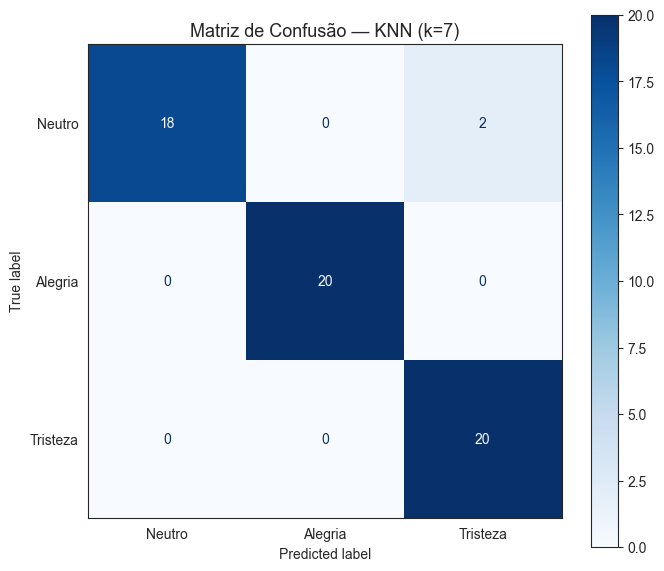

Leitura da matriz:
  Diagonal principal = predições corretas
  Fora da diagonal   = erros de classificação


In [24]:
fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_teste, y_pred,
    display_labels=list(nomes_classes.values()),
    cmap='Blues',
    ax=ax
)

ax.set_title('Matriz de Confusão — KNN (k=7)', fontsize=13)
plt.tight_layout()
plt.show()

print('Leitura da matriz:')
print('  Diagonal principal = predições corretas')
print('  Fora da diagonal   = erros de classificação')

---

## Parte 2: Pipeline do Scikit-learn

O `Pipeline` do sklearn encadeia transformadores e um estimador final. É a implementação oficial do padrão Pipeline que codamos do zero no notebook anterior.

**Vantagens:**
- Evita *data leakage* (vazamento de informação do teste para o treino)
- Exporta tudo como um único objeto
- Funciona com `GridSearchCV` automaticamente


##### 2.1 Pipeline: Scaler → PCA → Classificador

Pipeline (Scaler → PCA → KNN): 0.967

Etapas do pipeline:
  [scaler]: StandardScaler
  [pca]: PCA
  [clf]: KNeighborsClassifier

Variância explicada por componente PCA: [0.432 0.312 0.165]
Total: 0.909


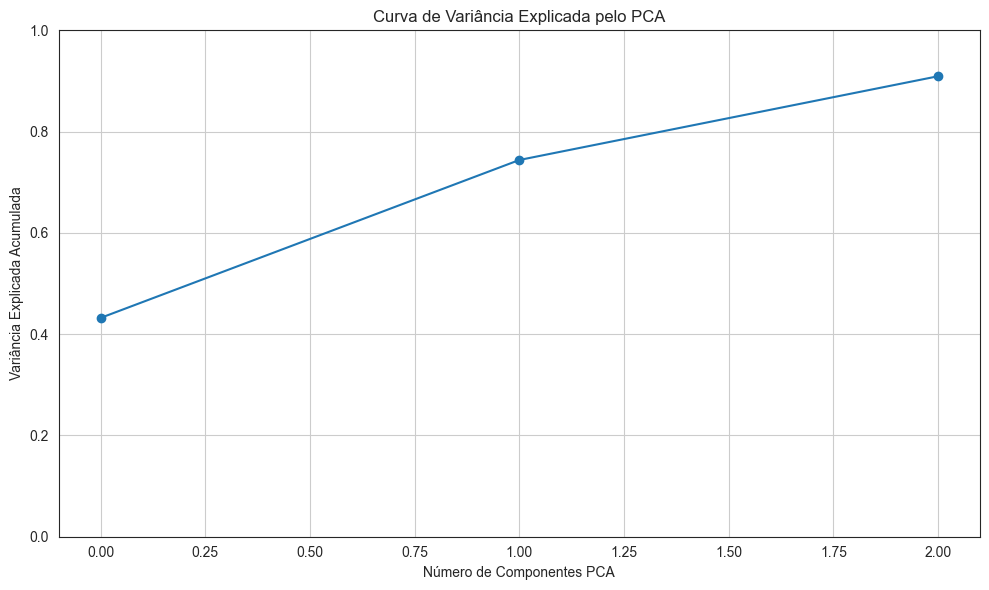

In [28]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),        # Passo 1: normalizar
    ('pca',   PCA(n_components=3)),      # Passo 2: reduzir dimensão
    ('clf',   KNeighborsClassifier(n_neighbors=5)),  # Passo 3: classificar
])

# Toda a lógica fit/transform/predict encadeada automaticamente!
pipeline.fit(X_treino, y_treino)

acuracia_pipe = pipeline.score(X_teste, y_teste)
print(f'Pipeline (Scaler → PCA → KNN): {acuracia_pipe:.3f}')

# Acessando etapas do pipeline
print('\nEtapas do pipeline:')
for nome, etapa in pipeline.steps:
    print(f'  [{nome}]: {type(etapa).__name__}')

# Variância explicada pelo PCA
pca = pipeline.named_steps['pca']
print(f'\nVariância explicada por componente PCA: {pca.explained_variance_ratio_.round(3)}')
print(f'Total: {pca.explained_variance_ratio_.sum():.3f}')

# plot da curva acumulativa da variância explicada
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Número de Componentes PCA')
plt.ylabel('Variância Explicada Acumulada')
plt.title('Curva de Variância Explicada pelo PCA')
plt.ylim([0,1])
plt.grid()
plt.tight_layout()
plt.show()

##### 2.2 Comparando múltiplos Pipelines

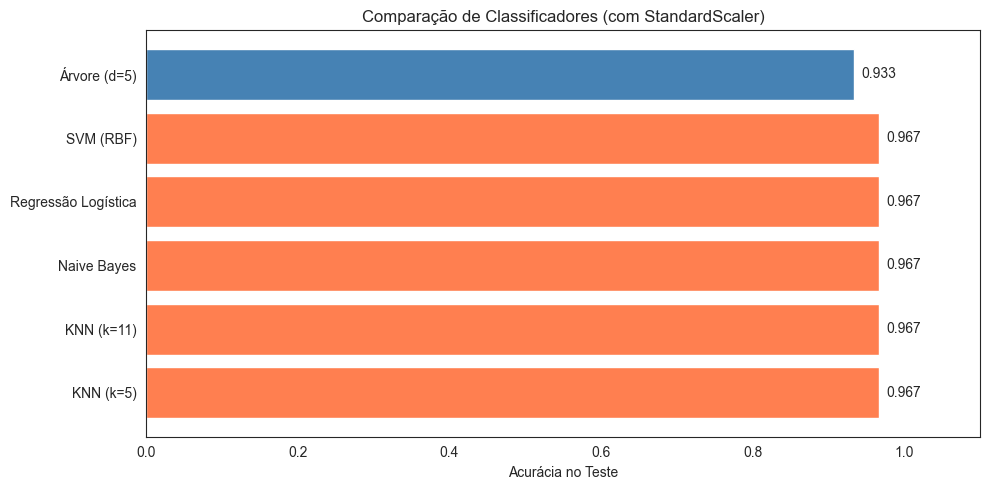

In [29]:
def criar_pipeline(clf):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', clf)
    ])

modelos = {
    'KNN (k=5)':          KNeighborsClassifier(n_neighbors=5),
    'KNN (k=11)':         KNeighborsClassifier(n_neighbors=11),
    'Naive Bayes':        GaussianNB(),
    'Regressão Logística':LogisticRegression(max_iter=1000, random_state=42),
    'SVM (RBF)':          SVC(kernel='rbf', C=1.0, random_state=42),
    'Árvore (d=5)':       DecisionTreeClassifier(max_depth=5, random_state=42),
}

resultados = {}
for nome, clf in modelos.items():
    pipe = criar_pipeline(clf)
    pipe.fit(X_treino, y_treino)
    acc = pipe.score(X_teste, y_teste)
    resultados[nome] = acc

# Visualização
fig, ax = plt.subplots(figsize=(10, 5))
nomes = list(resultados.keys())
acuracias = list(resultados.values())
cores = ['steelblue' if a < max(acuracias) else 'coral' for a in acuracias]

bars = ax.barh(nomes, acuracias, color=cores, edgecolor='white')
ax.set_xlabel('Acurácia no Teste')
ax.set_title('Comparação de Classificadores (com StandardScaler)')
ax.set_xlim(0, 1.1)
for bar, val in zip(bars, acuracias):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

---

## Parte 3: Validação Cruzada

Avaliar no mesmo conjunto de teste para escolher o melhor modelo é problemático — estamos "espionando" o teste! A validação cruzada resolve isso dividindo o treino em K dobras.

```
K=5:
Fold 1: [TEST] [─────────────────────────]
Fold 2: [────] [TEST] [──────────────────]
Fold 3: [────] [────] [TEST] [───────────]
Fold 4: [──────────────────] [TEST] [────]
Fold 5: [─────────────────────────] [TEST] ← na prática K tem 5 divisões
Resultado: média e desvio das 5 avaliações
```


##### 3.1 Cross-validation com cross_val_score

In [31]:
print('Validação cruzada (5-fold) para cada modelo:')
print(f'{"Modelo":<25} {"Média":>8} {"±Std":>8} {"Min":>8} {"Max":>8}')
print('-' * 60)

resultados_cv = {}
for nome, clf in modelos.items():
    pipe = criar_pipeline(clf)
    # cross_val_score usa apenas X_treino — o X_teste nunca é tocado!
    scores = cross_val_score(pipe, X_treino, y_treino, cv=5, scoring='accuracy')
    resultados_cv[nome] = scores
    print(f'{nome:<25} {scores.mean():>8.3f} {scores.std():>8.3f} '
          f'{scores.min():>8.3f} {scores.max():>8.3f}')

Validação cruzada (5-fold) para cada modelo:
Modelo                       Média     ±Std      Min      Max
------------------------------------------------------------
KNN (k=5)                    1.000    0.000    1.000    1.000
KNN (k=11)                   1.000    0.000    1.000    1.000
Naive Bayes                  1.000    0.000    1.000    1.000
Regressão Logística          1.000    0.000    1.000    1.000
SVM (RBF)                    1.000    0.000    1.000    1.000
Árvore (d=5)                 0.983    0.008    0.979    1.000


##### 3.2 Visualização dos resultados de CV

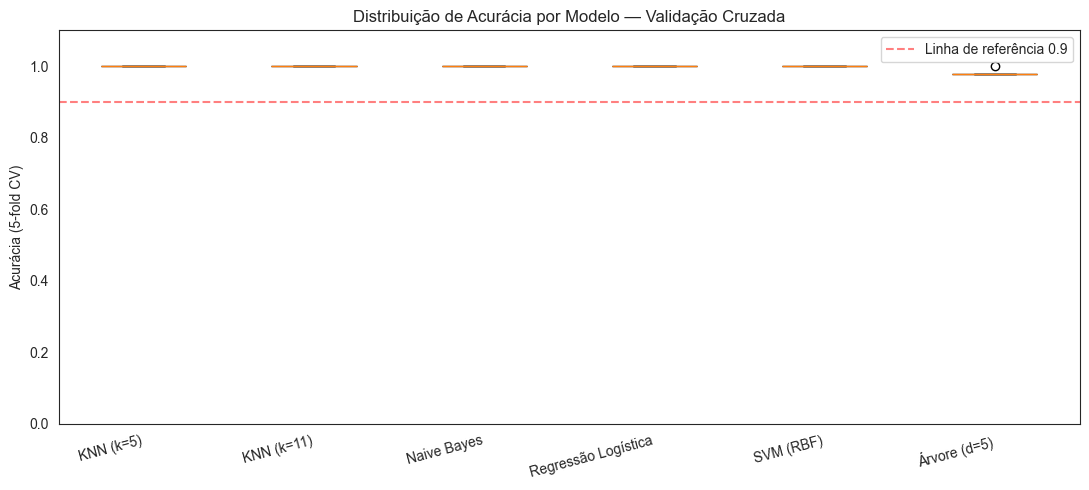

In [32]:
fig, ax = plt.subplots(figsize=(11, 5))

dados_box = [resultados_cv[n] for n in modelos.keys()]
bp = ax.boxplot(dados_box, patch_artist=True, notch=False)

# Colorindo as caixas
cores_box = plt.cm.Set3(np.linspace(0, 1, len(modelos)))
for patch, cor in zip(bp['boxes'], cores_box):
    patch.set_facecolor(cor)

ax.set_xticklabels(list(modelos.keys()), rotation=15, ha='right')
ax.set_ylabel('Acurácia (5-fold CV)')
ax.set_title('Distribuição de Acurácia por Modelo — Validação Cruzada')
ax.set_ylim(0, 1.1)
ax.axhline(y=0.9, color='red', linestyle='--', alpha=0.5, label='Linha de referência 0.9')
ax.legend()
plt.tight_layout()
plt.show()

---

## Parte 4: Busca de Hiperparâmetros com GridSearchCV

Hiperparâmetros são configurações do modelo que NÃO são aprendidas durante o treinamento (ex: `k` no KNN, profundidade máxima de uma árvore). `GridSearchCV` testa sistematicamente todas as combinações.


##### 4.1 GridSearchCV — encontrando o melhor k para KNN

In [33]:
pipeline_grid = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier())
])

# Grade de hiperparâmetros para explorar
# Notação: 'etapa__hiperparametro'
grade_params = {
    'clf__n_neighbors': [1, 3, 5, 7, 9, 11, 15, 21],
    'clf__metric': ['euclidean', 'manhattan'],
    'clf__weights': ['uniform', 'distance'],
}

grid_search = GridSearchCV(
    pipeline_grid,
    grade_params,
    cv=5,                    # 5-fold CV em cada combinação
    scoring='accuracy',
    n_jobs=-1,               # usa todos os núcleos da CPU
    verbose=0
)

grid_search.fit(X_treino, y_treino)

print('Melhores hiperparâmetros encontrados:')
for param, valor in grid_search.best_params_.items():
    print(f'  {param}: {valor}')
print(f'\nMelhor acurácia CV: {grid_search.best_score_:.3f}')
print(f'Acurácia no teste:  {grid_search.score(X_teste, y_teste):.3f}')

Melhores hiperparâmetros encontrados:
  clf__metric: euclidean
  clf__n_neighbors: 3
  clf__weights: uniform

Melhor acurácia CV: 1.000
Acurácia no teste:  0.967


##### 4.2 Visualizando o efeito de k na acurácia

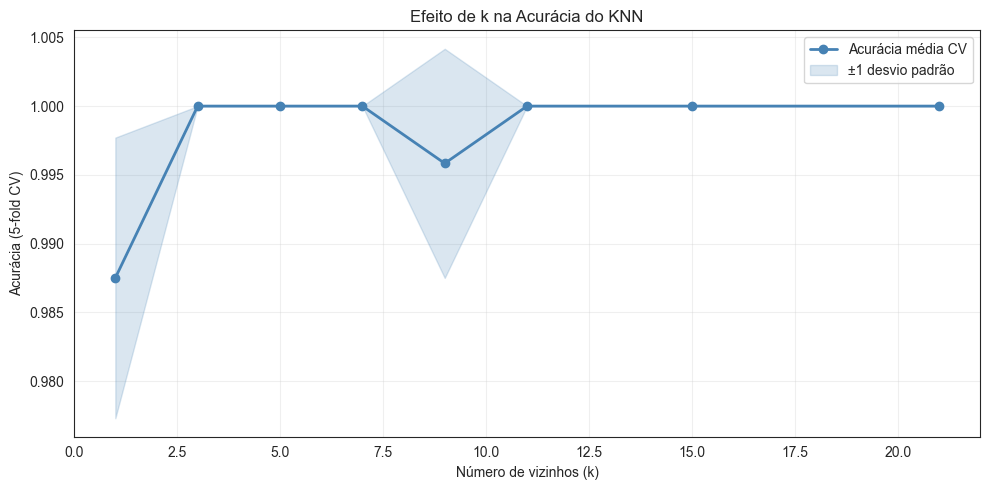

Observação: k muito pequeno = overfitting, k muito grande = underfitting.


In [35]:
resultados_df = pd.DataFrame(grid_search.cv_results_)

# Filtrando apenas métrica euclidiana e pesos uniformes
filtro = (
    (resultados_df['param_clf__metric'] == 'euclidean') &
    (resultados_df['param_clf__weights'] == 'uniform')
)
subset = resultados_df[filtro].sort_values('param_clf__n_neighbors')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(subset['param_clf__n_neighbors'],
        subset['mean_test_score'],
        marker='o', linewidth=2, color='steelblue', label='Acurácia média CV')
ax.fill_between(
    subset['param_clf__n_neighbors'],
    subset['mean_test_score'] - subset['std_test_score'],
    subset['mean_test_score'] + subset['std_test_score'],
    alpha=0.2, color='steelblue', label='±1 desvio padrão'
)
ax.set_xlabel('Número de vizinhos (k)')
ax.set_ylabel('Acurácia (5-fold CV)')
ax.set_title('Efeito de k na Acurácia do KNN')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Observação: k muito pequeno = overfitting, k muito grande = underfitting.')

##### 4.3 Curvas de Aprendizado (Learning Curves)

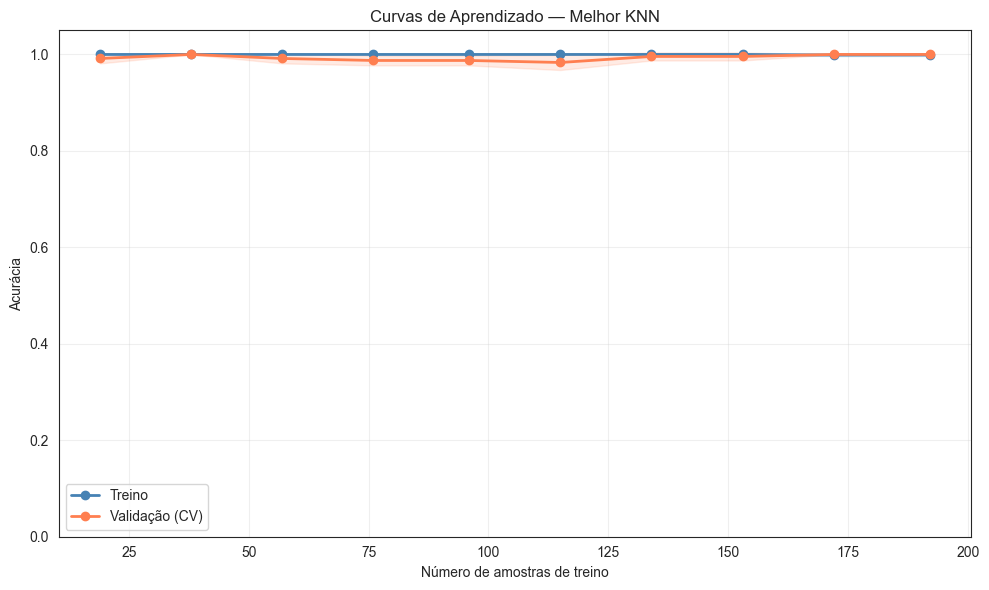

Interpretação:
  Treino >> Validação:  overfitting (modelo memoriza, não generaliza)
  Ambas baixas:         underfitting (modelo muito simples)
  Ambas altas e próximas: ótimo!


In [37]:
melhor_pipe = grid_search.best_estimator_

train_sizes, train_scores, val_scores = learning_curve(
    melhor_pipe, X_treino, y_treino,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy',
    n_jobs=-1
)

fig, ax = plt.subplots(figsize=(10, 6))

# Médias e intervalos de confiança
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Treino', linewidth=2)
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color='steelblue')

ax.plot(train_sizes, val_mean, 'o-', color='coral', label='Validação (CV)', linewidth=2)
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color='coral')

ax.set_xlabel('Número de amostras de treino')
ax.set_ylabel('Acurácia')
ax.set_title('Curvas de Aprendizado — Melhor KNN')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print('Interpretação:')
print('  Treino >> Validação:  overfitting (modelo memoriza, não generaliza)')
print('  Ambas baixas:         underfitting (modelo muito simples)')
print('  Ambas altas e próximas: ótimo!')

---

## Parte 5: Pré-processamento Avançado

### Lidando com dados categóricos e ausentes


##### 5.1 LabelEncoder — para variáveis categóricas como alvo

In [38]:
# Rótulos de texto para números
le = LabelEncoder()
labels_texto = ['alegria', 'neutro', 'tristeza', 'alegria', 'neutro']
labels_num   = le.fit_transform(labels_texto)

print('Labels originais:', labels_texto)
print('Labels numéricos:', labels_num)
print('Mapeamento:', dict(zip(le.classes_, range(len(le.classes_)))))

# Decodificando de volta
print('De volta ao texto:', le.inverse_transform(labels_num))

Labels originais: ['alegria', 'neutro', 'tristeza', 'alegria', 'neutro']
Labels numéricos: [0 1 2 0 1]
Mapeamento: {np.str_('alegria'): 0, np.str_('neutro'): 1, np.str_('tristeza'): 2}
De volta ao texto: ['alegria' 'neutro' 'tristeza' 'alegria' 'neutro']


##### 5.2 Imputação de valores ausentes

In [ ]:
# Dataset com valores ausentes
X_faltando = X_treino.copy()
idx_faltando = np.random.choice(len(X_faltando), size=20, replace=False)
X_faltando[idx_faltando, 0] = np.nan  # simula medições perdidas

print(f'Valores NaN antes: {np.isnan(X_faltando).sum()}')

imputer = SimpleImputer(strategy='mean')  # substitui NaN pela média da coluna
X_imputado = imputer.fit_transform(X_faltando)

print(f'Valores NaN após imputação: {np.isnan(X_imputado).sum()}')

# Pipeline completo com imputação
pipeline_completo = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler',  StandardScaler()),
    ('clf',     KNeighborsClassifier(n_neighbors=7))
])

# Agora funciona mesmo com NaN no conjunto de treino!
pipeline_completo.fit(X_faltando, y_treino)
print(f'\nAcurácia com pipeline robusto a NaN: {pipeline_completo.score(X_teste, y_teste):.3f}')

Valores NaN antes: 20
Valores NaN após imputação: 0

Acurácia com pipeline robusto a NaN: 0.983


##### 5.3 PCA — visualizando dados de alta dimensão

Componentes para 95% da variância: 16 de 20


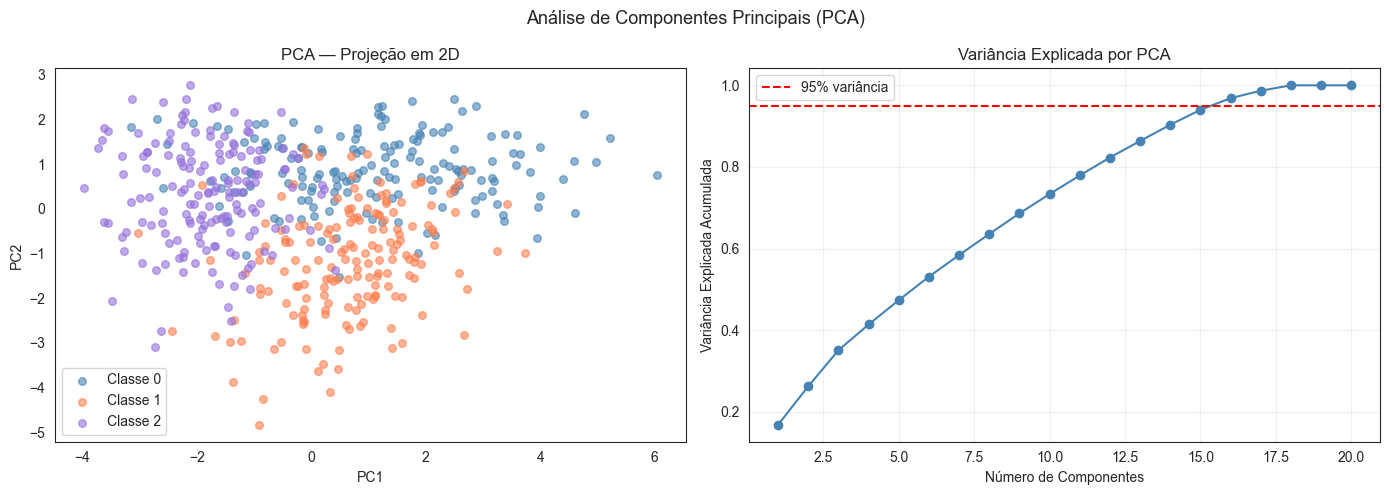

In [41]:
# Dataset com mais features
X_hd, y_hd = make_classification(
    n_samples=500, n_features=20, n_informative=10,
    n_classes=3, n_clusters_per_class=1, random_state=42
)

# PCA para 2 componentes (visualização)
pipe_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2)) # sempre tem que estar com dados escalonados/normalizados
])

X_2d = pipe_pca.fit_transform(X_hd)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 2D após PCA
cores = ['steelblue', 'coral', 'mediumpurple']
for cls in range(3):
    mask = y_hd == cls
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=cores[cls], alpha=0.6, label=f'Classe {cls}', s=30)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('PCA — Projeção em 2D')
axes[0].legend()

# Variância explicada por componente
pipe_pca_full = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA())
])
pipe_pca_full.fit(X_hd)
pca_full = pipe_pca_full.named_steps['pca']
var_cumulativa = np.cumsum(pca_full.explained_variance_ratio_)

axes[1].plot(range(1, len(var_cumulativa) + 1), var_cumulativa, 'o-', color='steelblue')
axes[1].axhline(y=0.95, color='red', linestyle='--', label='95% variância')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Variância Explicada Acumulada')
axes[1].set_title('Variância Explicada por PCA')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

n95 = np.argmax(var_cumulativa >= 0.95) + 1
print(f'Componentes para 95% da variância: {n95} de {X_hd.shape[1]}')

plt.suptitle('Análise de Componentes Principais (PCA)', fontsize=13)
plt.tight_layout()
plt.show()

---

## Exercício Integrador

Monte um experimento completo usando sklearn:

1. Gere um dataset com `make_blobs` de 4 classes e 8 features
2. Adicione 15% de valores NaN aleatoriamente
3. Crie um Pipeline: `SimpleImputer → StandardScaler → PCA(4) → SVC()`
4. Use `GridSearchCV` para otimizar `C` do SVC (`[0.1, 1, 10]`)
5. Avalie o melhor modelo com `classification_report` e matriz de confusão
6. Plote a curva de aprendizado do melhor modelo


In [ ]:
# === ESPAÇO PARA O EXERCÍCIO ===

# Seu código aqui...


---

## Resumo

| Conceito | Ferramenta | O que aprendemos |
|---|---|---|
| API Estimator | scikit-learn | Interface uniforme `fit` / `transform` / `predict` compartilhada por todos os estimadores |
| Normalização | `StandardScaler` | Escalar features para média 0 e desvio 1; sempre `fit` no treino e `transform` no teste |
| Classificação | KNN, NB, LR, SVM, DT | Comparar classificadores trocando apenas uma linha graças à API comum |
| Pipeline | `sklearn.Pipeline` | Encadear pré-processamento + modelo em um objeto único, evitando *data leakage* |
| Validação cruzada | `cross_val_score` | Avaliar modelos com K-fold sem tocar no conjunto de teste |
| Busca de hiperparâmetros | `GridSearchCV` | Testar sistematicamente combinações de parâmetros com CV embutida |
| Curvas de aprendizado | `learning_curve` | Diagnosticar overfitting (treino >> validação) e underfitting (ambas baixas) |
| Imputação | `SimpleImputer` | Tratar valores ausentes dentro do Pipeline de forma segura |
| Redução de dimensão | `PCA` | Comprimir features preservando a maior variância, útil para visualização |

**Próximo notebook:** Git e Versionamento de Projetos ML — estrutura de repositório, `.gitignore`, commits semânticos, rastreamento de experimentos em JSON e reprodutibilidade.